# Phase 1 — Business Understanding
**Pipeline:** `social_media_analytics`  
**Organization:** Lighthouse PH  
**CRISP-DM Phase:** 1 of 5  

---

## 1.1 Organizational Context

Lighthouse PH is a nonprofit rescue and rehabilitation center for survivors of human trafficking in the Philippines. Its social media presence — across Facebook, Instagram, Twitter/X, and WhatsApp — serves as a primary channel for donor acquisition, community engagement, and awareness campaigns.

The social media team publishes posts across platforms regularly, but post planning is currently intuition-driven. There is no systematic understanding of which post characteristics (platform, post type, media format, timing, topic, call-to-action style) predict whether a post will generate a donation — or how large that donation will be.

This pipeline addresses that gap.

## 1.2 Problem Statement

**Primary question:**  
> What characteristics of a social media post are most associated with generating estimated donation value in PHP?

**Secondary question:**  
> Which pre-publication post decisions (platform, type, media format, timing, topic) give the highest expected donation yield — enabling smarter post planning before a post goes live?

**Tertiary question (analytical only):**  
> How does post engagement (shares, likes, reach) mediate the relationship between post characteristics and donation outcomes?

**Target variable:**  `estimated_donation_value_php`  
**Unit of analysis:** One social media post  
**Dataset:** 812 posts from `pipeline/datasets/social_media_posts.csv`

## 1.3 Two-Stage Model Rationale

### Why a two-stage architecture?

The target `estimated_donation_value_php` is **zero-inflated**: a large fraction of posts generate exactly \$0. This violates the assumption of standard regression models, which would be biased toward predicting near-zero values and would systematically underestimate high-value posts.

A two-stage model separates the problem into two well-defined questions:

| Stage | Model type | Question answered | Target |
|---|---|---|---|
| **Stage 1** | Binary classifier | *Will this post generate any donation at all?* | `has_donation` (1 if value > 0) |
| **Stage 2** | Regressor | *Given it generates a donation, how large will it be?* | `log1p(estimated_donation_value_php)` on positive cases |

**Combined prediction:**
$$\hat{y}_{\text{PHP}} = P(\text{has\_donation}) \times e^{\hat{y}_{\text{log}}} - 1$$

This gives an *expected donation value* in PHP that correctly weights both the probability of any donation and the magnitude conditional on one occurring.

### Why log1p for Stage 2?

Donation values are right-skewed (a few posts drive disproportionately large donations). `log1p` compresses the scale, stabilizes variance, and prevents large outliers from dominating the regression loss.

## 1.4 Pre-Publication vs Post-Publication Feature Distinction

A critical design decision in this pipeline is the **temporal split** between features known before publishing and features available only after.

> **Leakage warning:** Post-publication engagement metrics (likes, shares, reach, etc.) are caused in part by donation behavior and audience response. Using them to *predict* donations in a production recommendation system would constitute **look-ahead leakage** — the system would be using information unavailable at decision time.

We address this by maintaining **two separate model artifacts**:

| | Explanatory model | Recommendation model |
|---|---|---|
| **Purpose** | Analytics dashboard — understand what drives value | React widget — score a planned post before publishing |
| **Features** | Pre-pub + post-pub | Pre-pub only |
| **Artifact** | `explanatory_model.joblib` | `recommendation_model.joblib` |
| **Leakage risk** | None (analysis only, not deployed for decisions) | None (only uses available inputs) |

### Pre-publication features (both models)

| Feature | Type | Description |
|---|---|---|
| `platform` | Categorical | Facebook, Instagram, Twitter/X, WhatsApp |
| `post_type` | Categorical | FundraisingAppeal, EducationalContent, etc. |
| `media_type` | Categorical | Photo, Video, Text, Reel, etc. |
| `sentiment_tone` | Categorical | Urgent, Grateful, Hopeful, etc. |
| `has_call_to_action` | Binary | Whether post includes a CTA |
| `call_to_action_type` | Categorical | Donate, LearnMore, Share, etc. |
| `post_hour` | Numeric | Hour of day (0–23) |
| `day_of_week` | Categorical | Monday–Sunday |
| `num_hashtags` | Numeric | Number of hashtags used |
| `caption_length` | Numeric | Character count of caption |
| `is_boosted` | Binary | Whether post was paid-boosted |
| `features_resident_story` | Binary | Whether post features a resident's personal story |
| `content_topic` | Categorical | Education, Awareness, Fundraising, etc. |
| `is_peak_hour` *(engineered)* | Binary | 1 if post_hour in {8–11, 17–20} |
| `is_peak_day` *(engineered)* | Binary | 1 if day_of_week in {Mon–Thu} |
| `has_video_content` *(engineered)* | Binary | 1 if media_type or post_type is video/reel |
| `is_impact_or_fundraising` *(engineered)* | Binary | 1 if topic/type relates to impact or fundraising |

### Post-publication features (explanatory model only)

| Feature | Description |
|---|---|
| `engagement_rate` | Interactions / impressions |
| `shares` | Number of shares |
| `likes` | Number of likes |
| `reach` | Unique accounts reached |
| `impressions` | Total impressions |
| `saves` | Number of saves |
| `click_throughs` | Link clicks |
| `profile_visits` | Profile visits from post |
| `video_views` | Video view count |
| `forwards` | Forwards/reposts |
| `engagement_per_follower` | Engagement rate normalized by follower count |

### Excluded features

| Feature | Reason excluded |
|---|---|
| `post_id`, `platform_post_id`, `post_url` | Identifiers — no predictive signal |
| `created_at` | Encoded via `post_hour` + `day_of_week` |
| `caption`, `hashtags` | Free text — NLP out of scope for this pipeline |
| `boost_budget_php` | Structural confound with `is_boosted` |
| `campaign_name` | High-cardinality label, not generalizable |
| `watch_time_seconds`, `avg_view_duration_seconds` | Sparse (non-video posts are null) |
| `subscriber_count_at_post`, `follower_count_at_post` | Slow-moving account-level metric, not post-level decision |
| `mentions_count` | Near-zero variance |


## 1.5 Feasibility Assessment

In [1]:
import sys
from pathlib import Path

# Allow imports from the pipeline root
PIPELINE_ROOT = Path(".").resolve().parent
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_io import load_csv
from src.features import engineer_features, build_targets

df_raw = load_csv()
df = engineer_features(df_raw)
df = build_targets(df)

print(f"Rows  : {len(df):,}")
print(f"Cols  : {df.shape[1]}")
print(f"\nTarget: estimated_donation_value_php")
print(df["estimated_donation_value_php"].describe().round(2).to_string())

Rows  : 812
Cols  : 45

Target: estimated_donation_value_php
count        812.00
mean       39772.09
std       124081.12
min            0.00
25%            0.00
50%         4556.96
75%        30072.07
max      2402435.96


In [2]:
# Zero-inflation check
n_zero    = (df["estimated_donation_value_php"] == 0).sum()
n_pos     = (df["estimated_donation_value_php"] > 0).sum()
pos_rate  = n_pos / len(df)

print(f"Posts with \$0 donation value : {n_zero:,}  ({1-pos_rate:.1%})")
print(f"Posts with > \$0 donation value: {n_pos:,}  ({pos_rate:.1%})")
print()
print("Stage 1 majority-class baseline:")
majority = max(n_zero, n_pos) / len(df)
print(f"  Predicting all-{'zero' if n_zero > n_pos else 'positive'} → accuracy = {majority:.1%}")
print("  Our Stage 1 target: ROC AUC ≥ 0.70 (meaningfully above 0.50 random baseline)")

Posts with \$0 donation value : 290  (35.7%)
Posts with > \$0 donation value: 522  (64.3%)

Stage 1 majority-class baseline:
  Predicting all-positive → accuracy = 64.3%
  Our Stage 1 target: ROC AUC ≥ 0.70 (meaningfully above 0.50 random baseline)


<>:6: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:7: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:6: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:7: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\apier\AppData\Local\Temp\ipykernel_20396\3387857341.py:6: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  print(f"Posts with \$0 donation value : {n_zero:,}  ({1-pos_rate:.1%})")
C:\Users\apier\AppData\Local\Temp\ipykernel_20396\3387857341.py:7: SyntaxWarning: "\$" is an invali

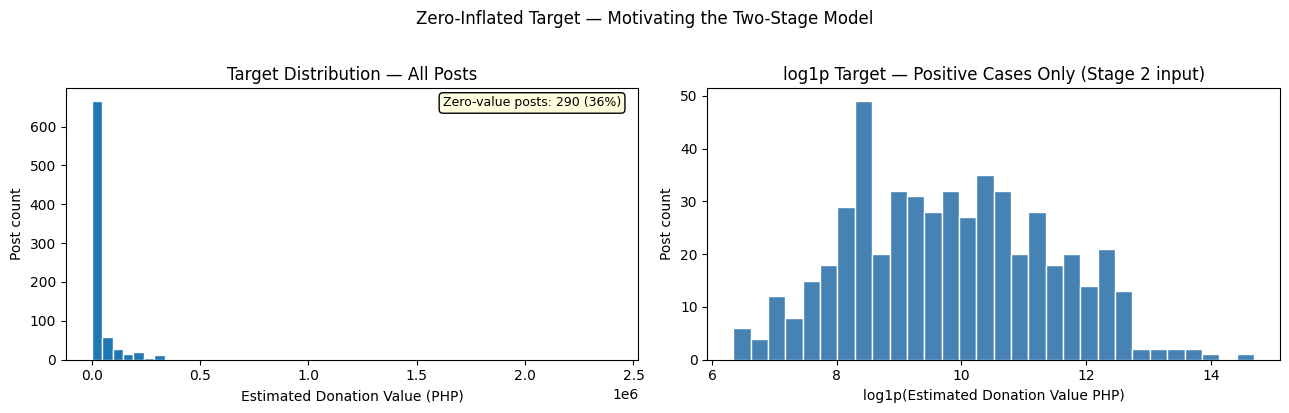

In [3]:
# Target distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: raw distribution (all posts)
axes[0].hist(df["estimated_donation_value_php"], bins=50, edgecolor="white")
axes[0].set_xlabel("Estimated Donation Value (PHP)")
axes[0].set_ylabel("Post count")
axes[0].set_title("Target Distribution — All Posts")
axes[0].text(
    0.97, 0.97,
    f"Zero-value posts: {n_zero:,} ({1-pos_rate:.0%})",
    transform=axes[0].transAxes,
    ha="right", va="top", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow")
)

# Right: log1p distribution (positive cases only)
pos_vals = df.loc[df["estimated_donation_value_php"] > 0, "log_donation_value"]
axes[1].hist(pos_vals, bins=30, edgecolor="white", color="steelblue")
axes[1].set_xlabel("log1p(Estimated Donation Value PHP)")
axes[1].set_ylabel("Post count")
axes[1].set_title("log1p Target — Positive Cases Only (Stage 2 input)")

plt.suptitle("Zero-Inflated Target — Motivating the Two-Stage Model", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# Signal check: do pre-publication features vary with donation outcome?
from src.config import PRE_PUB_FEATURES

print("Mean donation value by platform:")
print(df.groupby("platform")["estimated_donation_value_php"].mean().sort_values(ascending=False).round(2).to_string())
print()
print("Mean donation value by post_type:")
print(df.groupby("post_type")["estimated_donation_value_php"].mean().sort_values(ascending=False).round(2).to_string())
print()
print("Mean donation value by is_boosted:")
print(df.groupby("is_boosted")["estimated_donation_value_php"].mean().round(2).to_string())

Mean donation value by platform:
platform
WhatsApp     78438.10
YouTube      59060.76
TikTok       57424.57
LinkedIn     34921.29
Facebook     31086.19
Instagram    30989.33
Twitter      14264.21

Mean donation value by post_type:
post_type
ImpactStory           116160.67
FundraisingAppeal      36155.81
Campaign               28141.30
EducationalContent      3183.23
ThankYou                2927.61
EventPromotion          2762.69

Mean donation value by is_boosted:
is_boosted
0    34057.46
1    70595.14


### Feasibility verdict

| Criterion | Assessment |
|---|---|
| Sample size | 812 rows — small but sufficient for CV-validated modeling given low feature count |
| Target quality | Non-null, numeric, zero-inflated — handled by two-stage architecture |
| Pre-pub signal | Platform, post type, and boost status show variation in mean donation value (see above) |
| Feature availability | All pre-pub features present in CSV; post-pub features present but with some sparsity by platform |
| Leakage risk | Managed by explicit pre/post-pub split with two separate model artifacts |

**Feasibility: PROCEED.**

## 1.6 Success Criteria

| Stage | Metric | Minimum threshold | Rationale |
|---|---|---|---|
| Stage 1 (classifier) | ROC AUC | **≥ 0.70** | Substantially above 0.50 random baseline; indicates genuine signal in pre-pub features |
| Stage 2 (regressor) | R² | **≥ 0.35** | Accounts for ≥35% of variance in log donation value; meaningful improvement over mean-prediction baseline |
| Combined (recommendation model) | ROC AUC Stage 1 | **≥ 0.65** | Slightly relaxed — pre-pub features only, without post-engagement context |

These thresholds are conservative given the 812-row dataset. If Stage 2 R² falls below 0.35, the notebook will flag this and recommend the model be used for ranking/prioritization only — not point-estimate forecasting.

### Baseline comparisons

| Baseline | Description |
|---|---|
| Majority classifier | Always predict the dominant class in Stage 1 |
| Mean-prediction regressor | Always predict mean log-value in Stage 2 (R² = 0 by definition) |
| Per-platform mean | Predict average donation value for each platform — naive but interpretable |

All models must outperform these baselines to be considered useful.

## 1.7 Error Cost Analysis

The cost of errors is **asymmetric**:

| Error type | Description | Cost to Lighthouse PH |
|---|---|---|
| **False negative** (Stage 1) | Model predicts no donation, but post would have generated one | Staff under-invests in post; potential donation opportunity missed |
| **False positive** (Stage 1) | Model predicts donation, but post generates none | Staff over-invests; low opportunity cost (content is still published) |
| **Over-estimate** (Stage 2) | Model predicts high value, actual is low | Staff prioritizes the post; disappointing result but modest harm |
| **Under-estimate** (Stage 2) | Model predicts low value, actual is high | Staff doesn't prioritize; genuine missed opportunity |

**Implication for Stage 1:** False negatives are more costly than false positives. The classifier should be tuned to favor recall (catching all potential donation-generating posts), accepting lower precision. The `class_weight="balanced"` setting in both candidate classifiers reflects this.

**Implication for Stage 2:** Under-estimates are more costly. A conservative model that systematically under-predicts is less useful than one that occasionally over-predicts.

## 1.8 Stakeholder Impact

| Stakeholder | How they use the output |
|---|---|
| **Social media team** | Recommendation widget in React app — enter post details before publishing, get predicted donation tier and suggested improvements |
| **Program director** | Analytics dashboard — understand which campaigns and post formats drive the most donation value |
| **Fundraising team** | Prioritize paid boosts for posts with highest predicted value across platforms |
| **Data team** | `post_analytics_scores` table in Supabase — feeds downstream reporting and BI dashboards |

### Deliverables from this pipeline

| Deliverable | Description |
|---|---|
| `explanatory_model.joblib` | Full-feature model for dashboard SHAP analysis |
| `recommendation_model.joblib` | Pre-pub-only model for React widget |
| `post_analytics_scores` table | Supabase table: `post_id`, `predicted_value_php`, `p_has_donation`, `value_tier`, `scored_at` |
| CRISP-DM notebooks (01–05) | Documented analysis for reproducibility and stakeholder review |
| `master_crispdm_pipeline.ipynb` | Self-contained end-to-end notebook for stakeholder presentations |

## 1.9 Phase 1 Summary

| Decision | Choice |
|---|---|
| Target | `estimated_donation_value_php` (primary), `donation_referrals` (analytical only) |
| Model architecture | Two-stage: binary classifier (Stage 1) + log-scale regressor on positives (Stage 2) |
| Artifacts | Two separate joblib artifacts: explanatory (all features) + recommendation (pre-pub only) |
| Success criteria | Stage 1 ROC AUC ≥ 0.70; Stage 2 R² ≥ 0.35 |
| Error bias | Tune Stage 1 toward recall (false negatives more costly) |
| Leakage mitigation | Post-pub features excluded from recommendation model; documented in all notebooks |

**Phase 1 status: COMPLETE. Proceed to Phase 2 — Data Understanding.**